# 03— Chronos (Zero-Shot, 24h-Ahead PV Forecasting)

**Model:** Amazon Chronos-T5-Small (zero-shot, no fine-tuning)  
**Task:** 24-hour-ahead PV power forecasting at 15-minute resolution (96 steps)  
**Evaluation:**
- Primary: daytime samples (solar elevation > 5°)
- Secondary: all-hours (for completeness)
- Metric: MAE, RMSE, nRMSE, inference time per 24h window

**Run `01_data_processing.ipynb` first** to generate `data/dataset.csv`.

**Prerequisite:**
```bash
pip install chronos-forecasting
```

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time
import os
from tqdm import tqdm

import torch
from chronos import ChronosPipeline

if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
print(f'Device: {device}')

os.makedirs('../results', exist_ok=True)
os.makedirs('../figure',  exist_ok=True)

# ── Config ──
CONTEXT_LENGTH    = 512   # steps fed to model (~5.3 days at 15-min)
PREDICTION_LENGTH = 96    # 24h ahead at 15-min resolution
STRIDE            = 96    # step 1 day at a time
NUM_SAMPLES       = 20    # stochastic samples → take median
MAX_WINDOWS       = None  # set e.g. 10 for a quick smoke-test
MODEL_NAME        = 'Chronos'
MODEL_SIZE        = 'amazon/chronos-t5-small'

Device: mps


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/dataset.csv', index_col='timestamp', parse_dates=True)
df.index = df.index.tz_localize('UTC').tz_convert('Europe/Zagreb').tz_localize(None)

agg = {
    'power'             : 'sum',
    'sun_zenith'        : 'mean',
    'sun_azimuth'       : 'mean',
    'temperature'       : 'mean',
    'global_irradiance' : 'mean',
    'direct_irradiance' : 'mean',
    'diffuse_irradiance': 'mean',
}
df_full = df.resample('15min', closed='left', label='left').agg(agg)


df_full['power'] = df_full['power'].fillna(0).clip(lower=0)
wx_cols = [c for c in df_full.columns if c != 'power']
df_full[wx_cols] = df_full[wx_cols].ffill().fillna(0)

# Solar elevation (project daytime criterion: solar_elevation > 5°)
df_full['solar_elevation'] = (90 - df_full['sun_zenith']).clip(lower=0)

print(f'15-min grid shape: {df_full.shape}')
print(f'Range: {df_full.index.min()} → {df_full.index.max()}')

15-min grid shape: (171139, 8)
Range: 2018-04-17 07:15:00 → 2023-03-04 23:45:00


In [3]:
# Test period indices (same date split as baselines)
test_start = pd.Timestamp('2020-01-01')
test_end   = pd.Timestamp('2020-08-01')

full_series = df_full['power'].values.astype(np.float32)

test_mask      = (df_full.index >= test_start) & (df_full.index <= test_end)
test_indices   = np.where(test_mask)[0]
test_start_idx = int(test_indices[0])
test_end_idx   = int(test_indices[-1])

# Rolling window start positions
start_positions = list(range(test_start_idx, test_end_idx - PREDICTION_LENGTH + 1, STRIDE))
if MAX_WINDOWS:
    start_positions = start_positions[:MAX_WINDOWS]

print(f'Test: {test_start.date()} → {test_end.date()}')
print(f'Rolling windows: {len(start_positions)} × {PREDICTION_LENGTH} steps')

Test: 2020-01-01 → 2020-08-01
Rolling windows: 213 × 96 steps


## 2. Load Chronos Model

In [4]:
print(f'Loading {MODEL_SIZE} ...')
t_load = time.time()

pipeline = ChronosPipeline.from_pretrained(
    MODEL_SIZE,
    device_map=device,
    torch_dtype=torch.float32,
)

print(f'Model loaded in {time.time() - t_load:.1f}s')


def predict_chronos(context_array):
    """Run one 96-step Chronos forecast from a 1-D context array."""
    ctx = torch.tensor(context_array, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        forecast = pipeline.predict(
            ctx,
            prediction_length=PREDICTION_LENGTH,
            num_samples=NUM_SAMPLES,
        )
    # forecast: (1, num_samples, prediction_length) → take median
    return np.quantile(forecast[0].numpy(), 0.5, axis=0)

Loading amazon/chronos-t5-small ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Model loaded in 4.0s


## 3. Rolling 24h-Ahead Evaluation

In [5]:
n = len(start_positions)
all_preds   = np.zeros((n, PREDICTION_LENGTH), dtype=np.float32)
all_actuals = np.zeros((n, PREDICTION_LENGTH), dtype=np.float32)
all_ts      = []
infer_times = []

for w, i in enumerate(tqdm(start_positions, desc='Chronos rolling eval')):
    ctx_start = max(0, i - CONTEXT_LENGTH)
    context   = full_series[ctx_start:i]
    actual    = full_series[i:i + PREDICTION_LENGTH]
    ts        = df_full.index[i:i + PREDICTION_LENGTH]

    t0 = time.time()
    pred = predict_chronos(context)
    infer_times.append(time.time() - t0)

    all_preds[w]   = pred[:PREDICTION_LENGTH]
    all_actuals[w] = actual
    all_ts.append(ts)

print(f'Done. Avg inference time: {np.mean(infer_times):.3f}s per 24h window')

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

Done. Avg inference time: 1.622s per 24h window


## 4. Metrics — Daytime & All-Hours

In [6]:
preds_flat   = np.clip(all_preds.ravel(), 0, None)
actuals_flat = all_actuals.ravel()
ts_flat      = pd.DatetimeIndex(np.concatenate([t.values for t in all_ts]))

# Daytime mask: solar elevation > 5°
solar_elev   = df_full['solar_elevation'].reindex(ts_flat).values
day_mask     = solar_elev > 5

def metrics(y_true, y_pred, label):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / y_true.max()
    print(f'[{label}]  MAE={mae:.4f}  RMSE={rmse:.4f}  nRMSE={nrmse:.4f}')
    return mae, rmse, nrmse

print(f'\n=== {MODEL_NAME} ===')
mae_d, rmse_d, nrmse_d = metrics(actuals_flat[day_mask],  preds_flat[day_mask],  'Daytime')
mae_a, rmse_a, nrmse_a = metrics(actuals_flat,             preds_flat,            'All-hours')

avg_infer = np.mean(infer_times)
print(f'\nAvg inference time per 24h forecast: {avg_infer:.3f}s')
print(f'Daytime samples evaluated: {day_mask.sum()} / {len(day_mask)}')


=== Chronos ===
[Daytime]  MAE=0.1643  RMSE=0.2319  nRMSE=0.2698
[All-hours]  MAE=0.1047  RMSE=0.1881  nRMSE=0.2188

Avg inference time per 24h forecast: 1.622s
Daytime samples evaluated: 9930 / 20448


## 5. Plots

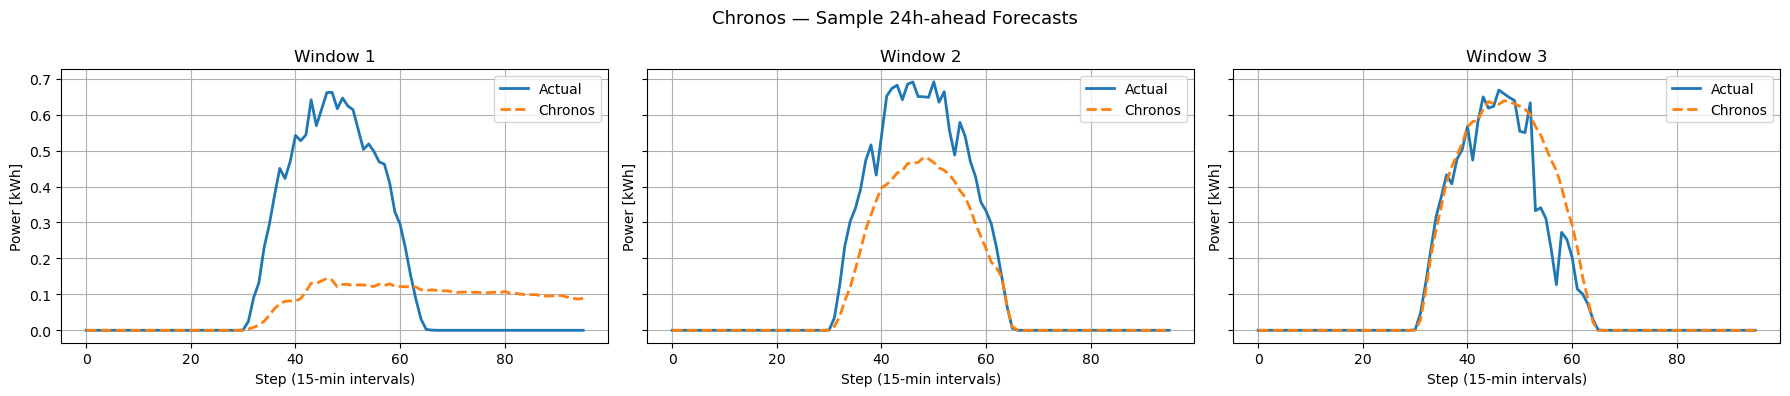

Saved → ../figure/03_chronos_sample_forecasts.png


In [7]:
# ── Sample forecast: first 3 sunny windows ──
sunny_windows = [
    w for w in range(n)
    if all_actuals[w].max() > 0.01  # has measurable production
][:3]

fig, axes = plt.subplots(1, len(sunny_windows), figsize=(6 * len(sunny_windows), 4), sharey=True)
if len(sunny_windows) == 1:
    axes = [axes]

for ax, w in zip(axes, sunny_windows):
    ax.plot(all_actuals[w],        label='Actual',   linewidth=2)
    ax.plot(all_preds[w],          label='Chronos',  linewidth=2, linestyle='--')
    ax.set_title(f'Window {w+1}')
    ax.set_xlabel('Step (15-min intervals)')
    ax.set_ylabel('Power [kWh]')
    ax.legend(); ax.grid(True)

plt.suptitle(f'{MODEL_NAME} — Sample 24h-ahead Forecasts', fontsize=13)
plt.tight_layout()
plt.savefig('../figure/03_chronos_sample_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/03_chronos_sample_forecasts.png')

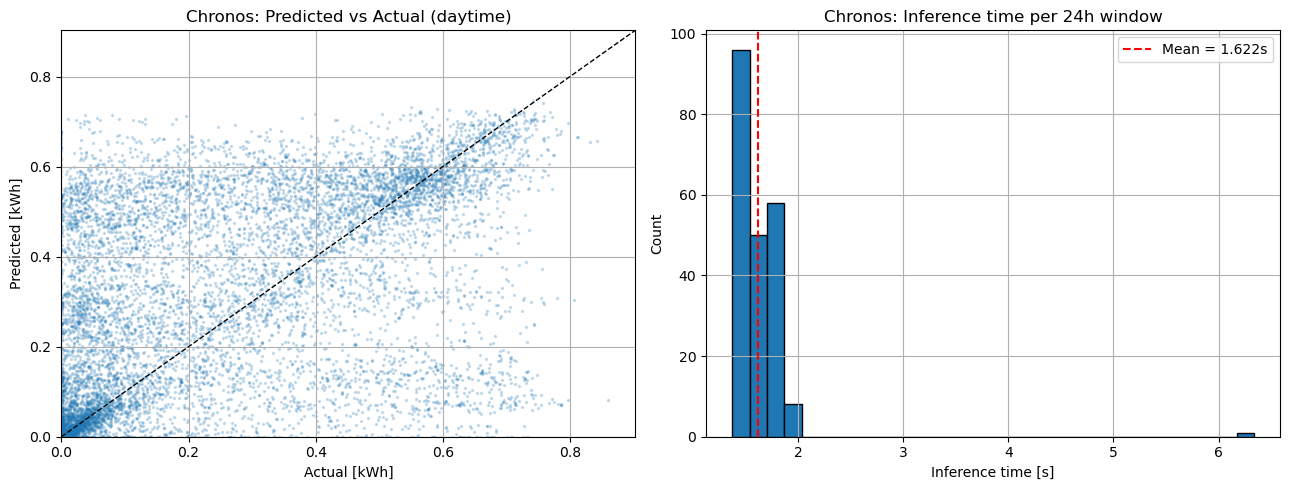

Saved → ../figure/03_chronos_eval.png


In [8]:
# ── Scatter: predicted vs actual (daytime) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = max(actuals_flat[day_mask].max(), preds_flat[day_mask].max()) * 1.05
axes[0].scatter(actuals_flat[day_mask], preds_flat[day_mask], s=2, alpha=0.2)
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel('Actual [kWh]'); axes[0].set_ylabel('Predicted [kWh]')
axes[0].set_title(f'{MODEL_NAME}: Predicted vs Actual (daytime)')
axes[0].grid(True)

# ── Inference time distribution ──
axes[1].hist(infer_times, bins=30, edgecolor='black')
axes[1].axvline(avg_infer, color='red', linestyle='--', label=f'Mean = {avg_infer:.3f}s')
axes[1].set_xlabel('Inference time [s]'); axes[1].set_ylabel('Count')
axes[1].set_title(f'{MODEL_NAME}: Inference time per 24h window')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('../figure/03_chronos_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/03_chronos_eval.png')

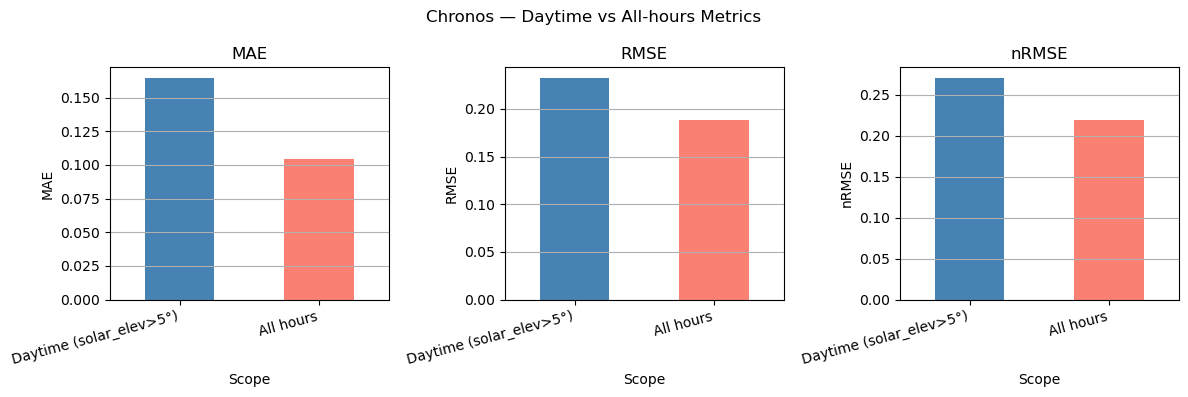

Saved → ../figure/03_chronos_daytime_vs_allhours.png


In [9]:
# ── Daytime vs all-hours bar chart ──
metrics_df = pd.DataFrame({
    'Scope'  : ['Daytime (solar_elev>5°)', 'All hours'],
    'MAE'    : [mae_d,   mae_a],
    'RMSE'   : [rmse_d,  rmse_a],
    'nRMSE'  : [nrmse_d, nrmse_a],
})

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['MAE', 'RMSE', 'nRMSE']):
    metrics_df.set_index('Scope')[col].plot(kind='bar', ax=ax, color=['steelblue','salmon'])
    ax.set_title(col); ax.set_ylabel(col); ax.grid(axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle(f'{MODEL_NAME} — Daytime vs All-hours Metrics', fontsize=12)
plt.tight_layout()
plt.savefig('../figure/03_chronos_daytime_vs_allhours.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/03_chronos_daytime_vs_allhours.png')

## 6. Save Results

In [10]:
# ── Prediction pickle ──
pd.DataFrame({
    'timestamp'  : ts_flat,
    'actual'     : actuals_flat,
    'chronos'    : preds_flat,
    'solar_elev' : solar_elev,
    'daytime'    : day_mask,
}).to_pickle('../results/chronos_predictions.pkl')
print('Saved → ../results/chronos_predictions.pkl')

Saved → ../results/chronos_predictions.pkl


In [11]:
# ── Append to shared comparison.csv ──
comp_path = '../results/comparison.csv'
comp_cols = ['Model', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'Inference Time']

new_rows = pd.DataFrame([
    {'Model': MODEL_NAME,               'MAE': mae_d, 'RMSE': rmse_d, 'nRMSE': nrmse_d,
     'Train Time': 0.0, 'Inference Time': avg_infer},
    {'Model': f'{MODEL_NAME} (all-hrs)', 'MAE': mae_a, 'RMSE': rmse_a, 'nRMSE': nrmse_a,
     'Train Time': 0.0, 'Inference Time': avg_infer},
])

if os.path.exists(comp_path):
    existing = pd.read_csv(comp_path)
    existing = existing[~existing['Model'].isin(new_rows['Model'])]
    combined = pd.concat([existing, new_rows], ignore_index=True)
else:
    combined = new_rows

combined[comp_cols].to_csv(comp_path, index=False)
print(f'Saved → {comp_path}')
print()
print(combined[comp_cols].to_string(index=False))

Saved → ../results/comparison.csv

            Model      MAE     RMSE    nRMSE  Train Time  Inference Time
         LightGBM 0.021175 0.034823 0.040512    0.196141        0.014383
 LightGBM (tuned) 0.020895 0.034539 0.040182   66.418172        0.037487
              MLP 0.020945 0.034464 0.040095    2.954158        0.017441
          Chronos 0.164308 0.231903 0.269790    0.000000        1.622153
Chronos (all-hrs) 0.104663 0.188088 0.218817    0.000000        1.622153
